# Set up directories

In [ ]:
import os

# Set the folder path
FOLDERPATH = r"C:\Users\petro\OneDrive\Desktop"  

# Check if the path exists
if not os.path.exists(FOLDERPATH):
    raise FileNotFoundError(f"The folder path {FOLDERPATH} does not exist. Please check the path.")

# Add the folder to Python's system path (if you want to import Python files from this folder)
import sys
sys.path.insert(1, FOLDERPATH)

# Change the working directory to the folder
os.chdir(FOLDERPATH)
print("Current Directory:", os.getcwd())

# List the files in the folder
print("Files in the folder:", os.listdir(FOLDERPATH))


Current Directory: C:\Users\petro\OneDrive\Desktop
Files in the folder: ['01+Data+Collection+Preparation.ipynb', '02 Κομμάτι 2.wma', 'Anaconda3-2024.06-1-Windows-x86_64.exe', 'desktop.ini', 'Discord.lnk', 'DiscordSetup.exe', 'exams', 'exams.tar.gz', 'gag', 'gag.tar.bz2', 'gagOntology.rdf', 'GraphDB Desktop.lnk', 'GraphDB_Desktop-10.8.0.msi', 'Greek_Admin_Geography_SPARKQL.docx', 'Homework1_Exercise1_Wikidata.pdf', 'Homework_Submission.zip', 'KT_L03_RDF_RDFS_SPARQL (1).ppt', 'KT_L03_RDF_RDFS_SPARQL.ppt', 'LAB 4 SOLVES pytorch_transformers', 'LAB 4 SOLVES pytorch_transformers.ipynb', 'Lab1 Gerostathos_Petros.zip', 'Lab2 Gerosstathos_Petros.zip', 'Lab3 Gerostathos_Petros (1).zip', 'Lab3 Gerostathos_Petros.zip', 'lab_3_2024_2025', 'Lab_3_solves pytorch_convnets.ipynb', 'lab_4_2024_2025', 'lab_4_2024_2025.zip', 'Machine Learning 1st Assignment 2024-2025.rar', 'Machine Learning Mid Term Exam December 2024.pdf', 'ontologyDescription.pdf', 'ProjectDescription.txt', 'pytorch_convnets.ipynb', 'q

# GPU

In [9]:
import torch

print("PyTorch version:", torch.__version__)
print("Is CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU found.")


PyTorch version: 2.5.1+cu118
Is CUDA available: True
GPU Device Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as datasets
import torchvision.transforms as T

import numpy as np
import math
from tqdm import tqdm

USE_GPU = True
dtype = torch.float32 



if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


# Preparation and Visualization

## Load CIFAR-10 dataset

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

mean = (0.4914, 0.4822, 0.4465)  # Precomputed mean for CIFAR-10
std = (0.2023, 0.1994, 0.2010)   # Precomputed std for CIFAR-10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load the CIFAR-10 dataset
dataset_path = "/mnt/data/datasets/" 
cifar10_dataset = datasets.CIFAR10(root=dataset_path, train=True, download=True, transform=transform) 

# Split the dataset 
num_train = 45000  
num_val = 5000    
num_test = 10000   

train_dataset, val_dataset = random_split(cifar10_dataset, [num_train, num_val])

test_dataset = datasets.CIFAR10(root=dataset_path, train=False, download=True, transform=transform)

# Define DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Files already downloaded and verified
Files already downloaded and verified
Train set size: 45000
Validation set size: 5000
Test set size: 10000


## Visualize the class distributions

In [12]:
import numpy as np
from collections import Counter

def get_class_distribution(loader, dataset_classes):
    """
    Computes the distribution of classes in a DataLoader.

    Args:
    - loader: DataLoader to inspect
    - dataset_classes: List of class names for the dataset

    Returns:
    - class_counts: Dictionary with class names as keys and counts as values
    """
    class_counts = Counter()
    for inputs, labels in loader:
        class_counts.update(labels.numpy())

    # Convert to a dictionary with class names
    class_distribution = {dataset_classes[i]: class_counts[i] for i in range(len(dataset_classes))}
    return class_distribution

def display_class_distribution(distribution, title="Class Distribution"):
    """
    Displays the class distribution as a bar chart.

    Args:
    - distribution: Dictionary with class names as keys and counts as values
    - title: Title for the bar chart
    """
    import matplotlib.pyplot as plt

    class_names = list(distribution.keys())
    counts = list(distribution.values())

    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [13]:
!pip install matplotlib



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\petro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Train DataLoader Distribution:
  airplane: 4478
  automobile: 4510
  bird: 4524
  cat: 4492
  deer: 4490
  dog: 4545
  frog: 4497
  horse: 4487
  ship: 4508
  truck: 4469


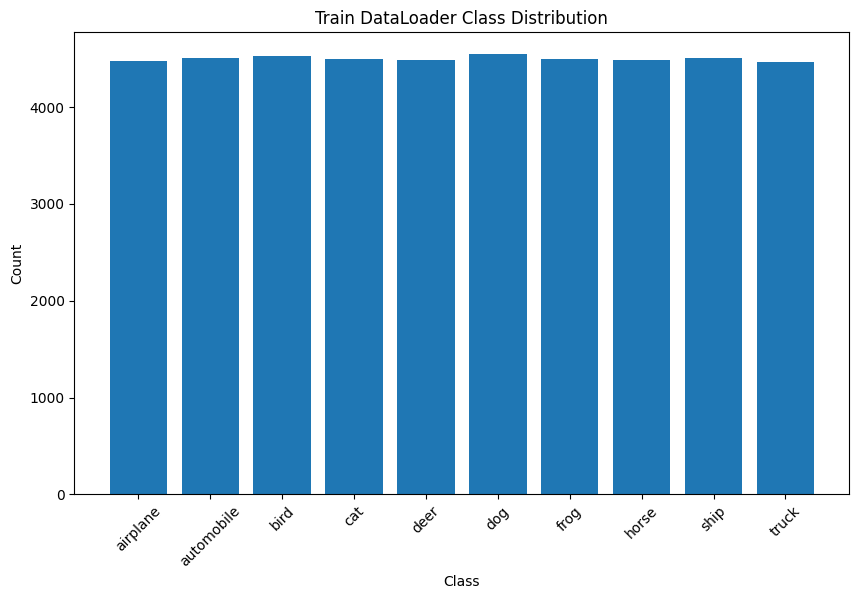

Validation DataLoader Distribution:
  airplane: 522
  automobile: 490
  bird: 476
  cat: 508
  deer: 510
  dog: 455
  frog: 503
  horse: 513
  ship: 492
  truck: 531


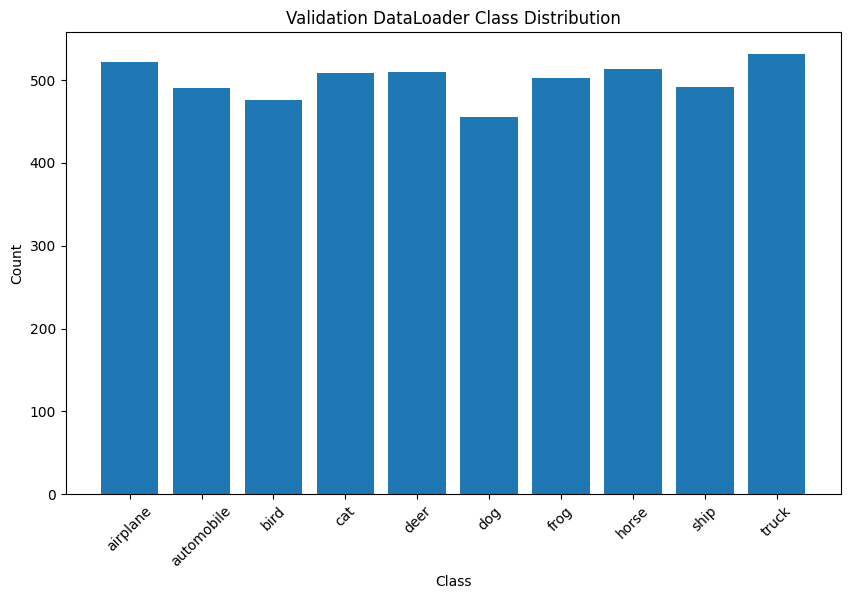

Test DataLoader Distribution:
  airplane: 1000
  automobile: 1000
  bird: 1000
  cat: 1000
  deer: 1000
  dog: 1000
  frog: 1000
  horse: 1000
  ship: 1000
  truck: 1000


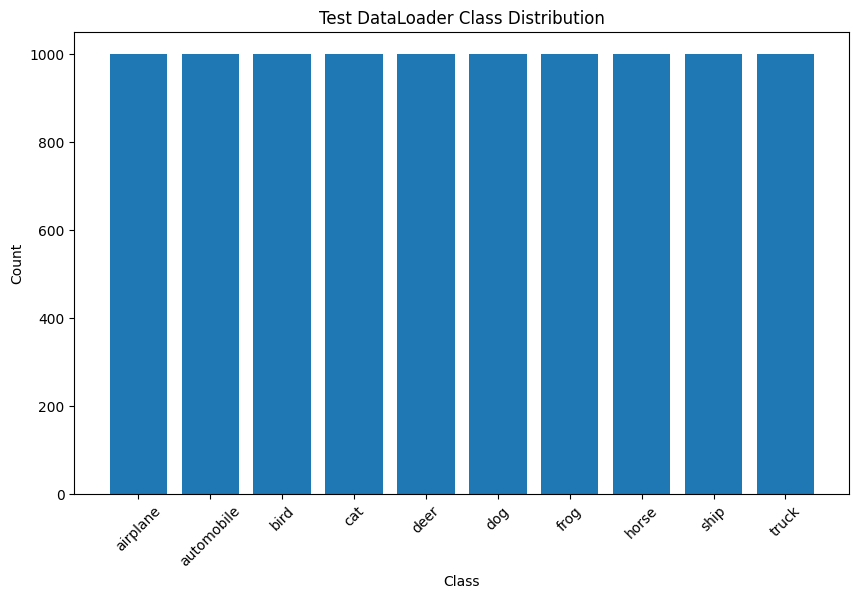

In [14]:
# CIFAR-10 classes
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Compute and display class distribution for each DataLoader
for loader, name in [(train_loader, "Train"), (val_loader, "Validation"), (test_loader, "Test")]:
    distribution = get_class_distribution(loader, cifar10_classes)
    print(f"{name} DataLoader Distribution:")
    for cls, count in distribution.items():
        print(f"  {cls}: {count}")
    display_class_distribution(distribution, title=f"{name} DataLoader Class Distribution")

## Visualize CIFAR-10 images

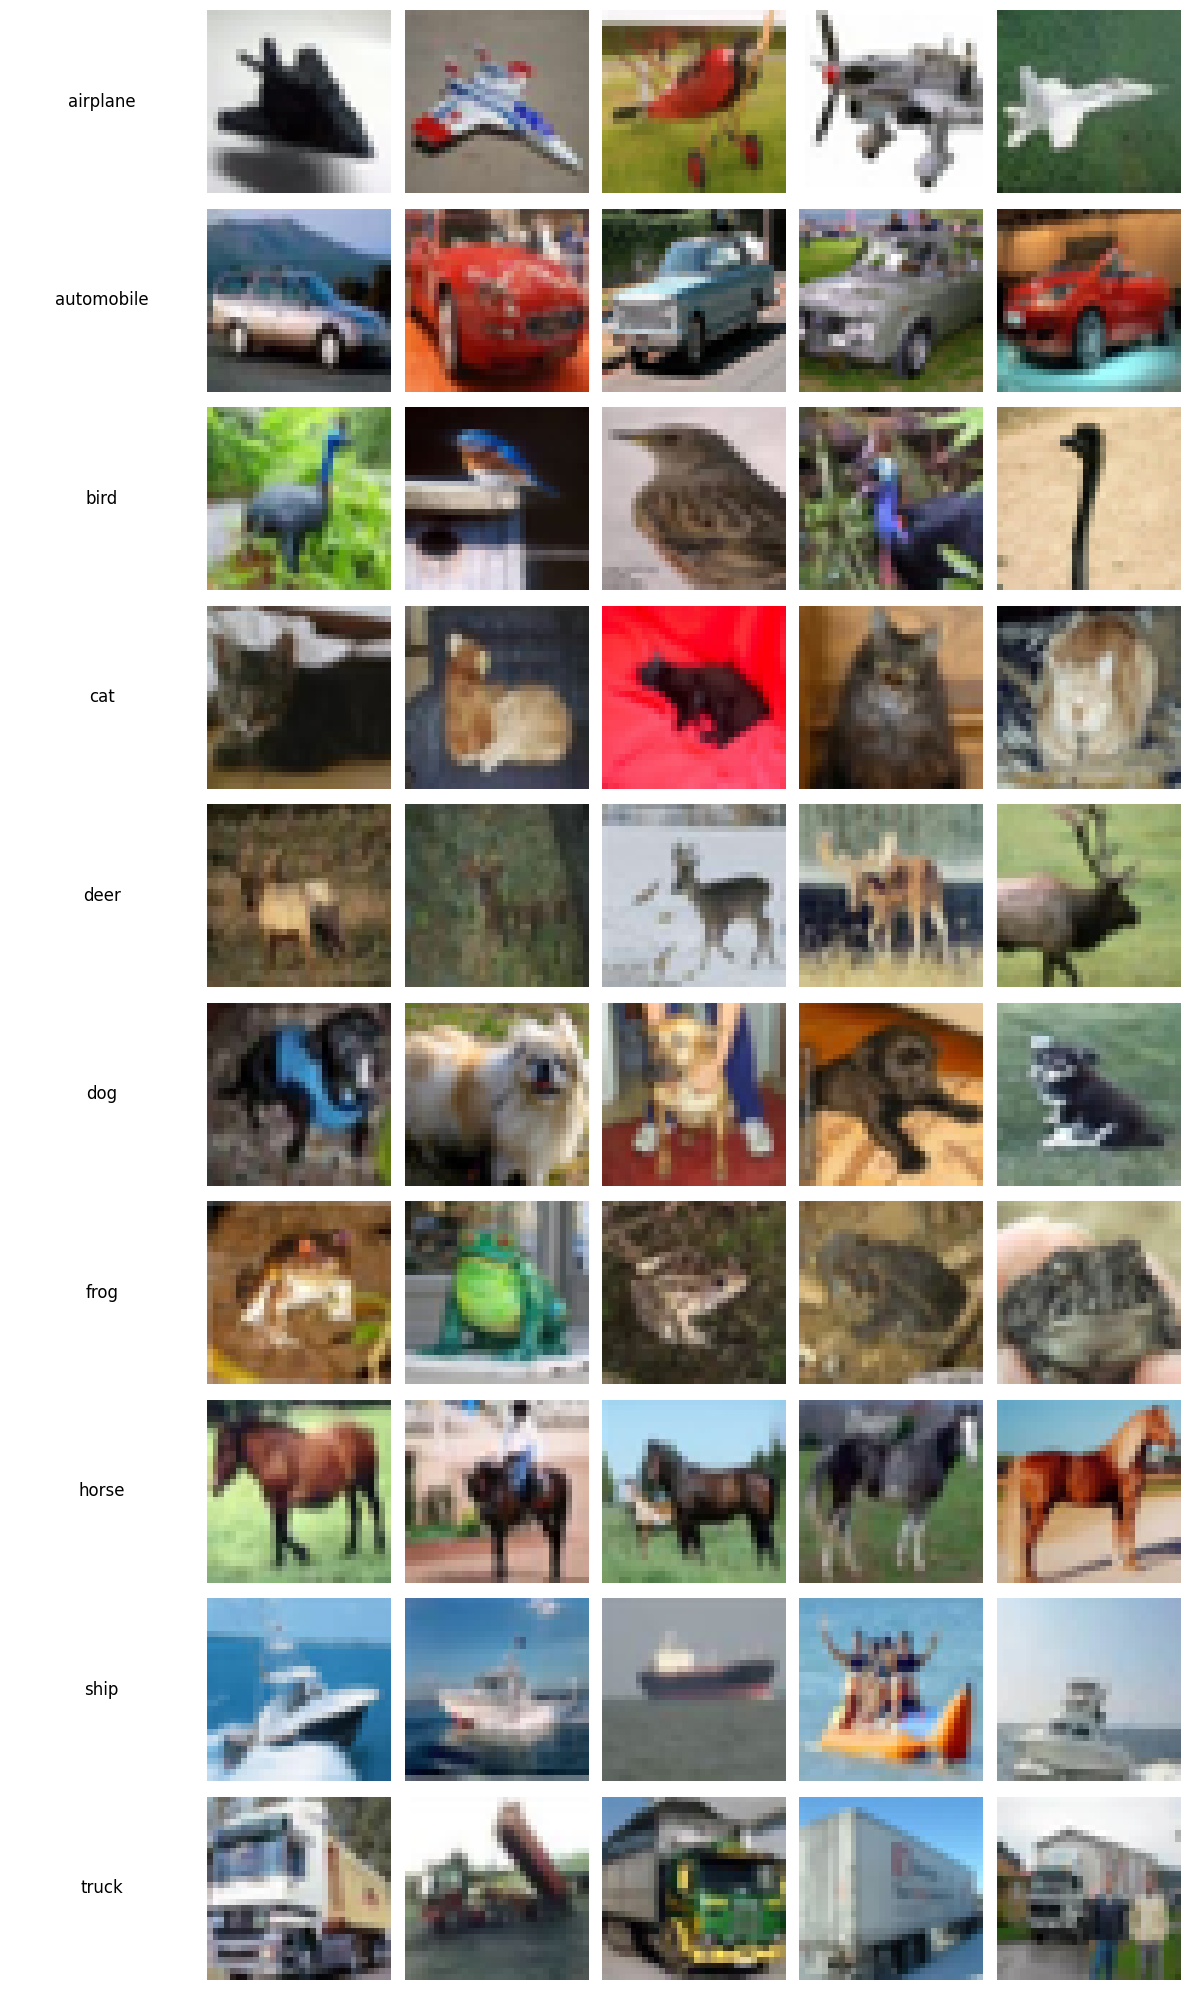

In [15]:
import matplotlib.pyplot as plt

def visualize_images_per_class(dataset, dataset_classes, num_images=5):
    """
    Visualizes a few images from each class in the dataset.

    Args:
    - dataset: The dataset to sample from.
    - dataset_classes: List of class names for the dataset.
    - num_images: Number of images to display per class.
    """
    class_to_indices = {cls: [] for cls in range(len(dataset_classes))}

    # Group indices by class
    for idx, (_, label) in enumerate(dataset):
        if len(class_to_indices[label]) < num_images:
            class_to_indices[label].append(idx)
        if all(len(indices) == num_images for indices in class_to_indices.values()):
            break

    # Plot the images
    fig, axes = plt.subplots(len(dataset_classes), num_images + 1, figsize=((num_images + 1) * 2, len(dataset_classes) * 2))
    for cls_idx, cls_name in enumerate(dataset_classes):
        indices = class_to_indices[cls_idx]

        # Add class name to the first column of each row
        axes[cls_idx, 0].text(0.5, 0.5, cls_name, fontsize=12, ha='center', va='center', transform=axes[cls_idx, 0].transAxes)
        axes[cls_idx, 0].axis("off")

        for img_idx, data_idx in enumerate(indices):
            img, label = dataset[data_idx]
            ax = axes[cls_idx, img_idx + 1]  # Shift by 1 for the class name column
            img = img.permute(1, 2, 0)  # Convert CHW to HWC
            img = img * torch.tensor(std).view(1, 1, 3) + torch.tensor(mean).view(1, 1, 3)  # De-normalize
            img = torch.clamp(img, 0, 1)  # Clip values to valid range
            ax.imshow(img)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize 5 images per class for CIFAR-10 train set
visualize_images_per_class(cifar10_dataset, cifar10_classes, num_images=5)

# Custom Vision Transformer with Pytorch Module API

## Module API: Patch Embedding

In [ ]:
class PatchEmbedding(nn.Module):
    """
    Converts an image into a sequence of flattened patches and projects them into a vector space.

    Parameters:
    - config: A dictionary containing the following keys:
        - "image_size" (int): The height and width of the input image (assumes square images).
        - "patch_size" (int): The height and width of each patch (assumes square patches).
        - "num_channels" (int): The number of input channels (e.g., 3 for RGB images).
        - "hidden_size" (int): The dimensionality of the output embedding for each patch.
    """

    def __init__(self, config):
        super().__init__()
        # Extract configuration parameters
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.num_channels = config["num_channels"]
        self.hidden_size = config["hidden_size"]
        self.num_patches = (self.image_size // self.patch_size) ** 2
        self.projection = nn.Conv2d(
            in_channels=self.num_channels,
            out_channels=self.hidden_size,
            kernel_size=self.patch_size,
            stride=self.patch_size
        )


    def forward(self, x):
        """
        Forward pass:
        - Input: A batch of images with shape (batch_size, num_channels, image_size, image_size)
        - Output: A tensor of shape (batch_size, num_patches, hidden_size), where each patch is projected into a hidden vector space.
        """
        x = self.projection(x)
        batch_size, hidden_size, num_patches_h, num_patches_w = x.shape
        x = x.flatten(2)
        x = x.transpose(1, 2)

        return x

## Module API: Embeddings

In [ ]:
class Embeddings(nn.Module):
    """
    Combines patch embeddings with the [CLS] token and position embeddings.

    This module performs the following steps:
    1. Generates patch embeddings for the input image.
    2. Adds a learnable [CLS] token at the beginning of the sequence.
    3. Adds positional embeddings to encode the spatial information.
    4. Applies dropout for regularization.

    Parameters:
    - config (dict): A dictionary containing the following keys:
        - "image_size" (int): The height and width of the input image (assumes square images).
        - "patch_size" (int): The height and width of each patch (assumes square patches).
        - "num_channels" (int): The number of input channels (e.g., 3 for RGB images).
        - "hidden_size" (int): The dimensionality of the patch embeddings and transformer embeddings.
        - "hidden_dropout_prob" (float): Dropout probability applied after adding positional embeddings.
    """

    def __init__(self, config):
        super().__init__()
        # Save configuration
        self.config = config
        self.patch_embeddings = PatchEmbedding(config)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, config["hidden_size"]))
        num_patches = (config["image_size"] // config["patch_size"]) ** 2
        self.pos_embeddings = nn.Parameter(torch.zeros(1, num_patches + 1, config["hidden_size"]))
        # Dropout for regularization
        self.dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x):
        """
        Forward pass:
        - Input: A batch of images of shape (batch_size, num_channels, image_size, image_size)
        - Output: A sequence of embeddings of shape (batch_size, num_patches + 1, hidden_size)
        """
        x = self.patch_embeddings(x)
        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embeddings
        # Apply dropout
        x = self.dropout(x)

        return x

## Module API: Attention head

In [ ]:
class AttentionHead(nn.Module):
    """
    Implements a single attention head for self-attention.

    This module performs the following steps:
    1. Projects the input into query, key, and value vectors.
    2. Computes scaled dot-product attention:
        - attention(Q, K, V) = softmax(Q * K^T / sqrt(d_k)) * V
    3. Applies dropout to the attention probabilities for regularization.

    Parameters:
    - hidden_size (int): Dimensionality of the input embeddings.
    - attention_head_size (int): Dimensionality of each attention head.
    - dropout (float): Dropout probability applied to attention probabilities.
    - bias (bool): Whether to include biases in the projection layers (default: True).
    """

    def __init__(self, hidden_size, attention_head_size, dropout, bias=True):
        super().__init__()
        # Save dimensions
        self.hidden_size = hidden_size
        self.attention_head_size = attention_head_size
        self.query = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.key = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.value = nn.Linear(hidden_size, attention_head_size, bias=bias)
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Forward pass:
        - Input: A tensor of shape (batch_size, sequence_length, hidden_size)
        - Output:
          - attention_output: A tensor of shape (batch_size, sequence_length, attention_head_size)
          - attention_probs: The attention probabilities (batch_size, sequence_length, sequence_length)
        """
        # Compute query, key, and value vectors
        query = self.query(x)  # Shape: (batch_size, sequence_length, attention_head_size)
        key = self.key(x)      # Shape: (batch_size, sequence_length, attention_head_size)
        value = self.value(x)  # Shape: (batch_size, sequence_length, attention_head_size)
        key_transpose = key.transpose(-1, -2)
        attention_scores = torch.matmul(query, key_transpose)
        attention_scores = attention_scores / torch.sqrt(torch.tensor(self.attention_head_size, dtype=torch.float32))
        attention_probs = F.softmax(attention_scores, dim=-1)
        # Apply dropout to attention probabilities
        attention_probs = self.dropout(attention_probs)
        attention_output = torch.matmul(attention_probs, value)

        return attention_output, attention_probs

## Module API: Multi-head self-attention (MHSA)

In [ ]:
class MultiHeadAttention(nn.Module):
    """
    Implements the multi-head attention mechanism for transformers.

    Multi-head attention allows the model to jointly focus on different parts of the input sequence by splitting
    the attention computation across multiple attention heads. This module:
    1. Computes attention for each head independently using the `AttentionHead` module.
    2. Concatenates the outputs from all heads.
    3. Projects the concatenated output back to the hidden size dimension.

    Parameters:
    - config (dict): Configuration dictionary containing:
        - "hidden_size" (int): Dimensionality of the input and output embeddings.
        - "num_attention_heads" (int): Number of attention heads.
        - "qkv_bias" (bool): Whether to include biases in query, key, and value projections.
        - "attention_probs_dropout_prob" (float): Dropout probability for attention probabilities.
        - "hidden_dropout_prob" (float): Dropout probability for the output projection layer.
    """

    def __init__(self, config):
        super().__init__()

        # Extract configuration parameters
        self.hidden_size = config["hidden_size"]
        self.num_attention_heads = config["num_attention_heads"]
        self.qkv_bias = config["qkv_bias"]
        self.attention_head_size = self.hidden_size // self.num_attention_heads
        assert (
            self.hidden_size % self.num_attention_heads == 0
        ), "hidden_size must be divisible by num_attention_heads."

        # Total size of all heads combined
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.hidden_size, self.attention_head_size, config["attention_probs_dropout_prob"], self.qkv_bias)
            for _ in range(self.num_attention_heads)
        ])

        self.output_projection = nn.Linear(self.all_head_size, self.hidden_size)
        # Define dropout for the output projection
        self.output_dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x, output_attentions=False):
        """
        Forward pass for multi-head attention.

        Parameters:
        - x (Tensor): Input tensor of shape (batch_size, sequence_length, hidden_size).
        - output_attentions (bool): If True, returns attention probabilities for each head.

        Returns:
        - attention_output (Tensor): Output tensor of shape (batch_size, sequence_length, hidden_size).
        - attention_probs (Tensor, optional): Attention probabilities for each head of shape
          (batch_size, num_heads, sequence_length, sequence_length) if `output_attentions` is True.
        """
        attention_outputs = [head(x) for head in self.attention_heads]
        head_outputs = [output for output, _ in attention_outputs]
        attention_probs = [probs for _, probs in attention_outputs]
        concatenated_outputs = torch.cat(head_outputs, dim=-1)
        attention_output = self.output_projection(concatenated_outputs)
        attention_output = self.output_dropout(attention_output)

        # Return attention probabilities
        if output_attentions:
            attention_probs = torch.stack(
                [attention_probs for _, attention_probs in attention_outputs], dim=1
            )  # Shape: (batch_size, num_heads, sequence_length, sequence_length)
            return attention_output, attention_probs

        return attention_output, None

## Module API: Multi-layer Perceptron (MLP)

In [ ]:
class MLP(nn.Module):
    """
    Implements a multi-layer perceptron (MLP) module for transformers.

    This module applies the following steps:
    1. A fully connected (dense) layer that expands the input dimension.
    2. A non-linear activation function (e.g., GELU).
    3. A second fully connected layer that projects the expanded dimension back to the input size.
    4. Dropout for regularization.

    Parameters:
    - config (dict): Configuration dictionary containing:
        - "hidden_size" (int): Dimensionality of the input and output embeddings.
        - "intermediate_size" (int): Dimensionality of the expanded hidden layer.
        - "hidden_dropout_prob" (float): Dropout probability applied after the second dense layer.
    """

    def __init__(self, config):
        super().__init__()
        self.fc1 = nn.Linear(config["hidden_size"], config["intermediate_size"])
        self.activation = nn.GELU()
        self.fc2 = nn.Linear(config["intermediate_size"], config["hidden_size"])
        # Dropout for regularization
        self.dropout = nn.Dropout(config["hidden_dropout_prob"])

    def forward(self, x):
        """
        Forward pass:
        - Input: A tensor of shape (batch_size, sequence_length, hidden_size).
        - Output: A tensor of shape (batch_size, sequence_length, hidden_size).
        """
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        # Apply dropout
        x = self.dropout(x)

        return x

## Module API: Transformer Block

In [ ]:
class Block(nn.Module):
    """
    Implements a siModule API: Transformer Block
The Block module implements a single transformer block, which combines multi-head self-attention (MHSA) and a feed-forward network (MLP), each followed by layer normalization and residual connections.

Key Steps:
Apply Layer Normalization before the self-attention mechanism.
Compute Multi-Head Self-Attention and add a residual connection (skip connection).
Apply Layer Normalization before the feed-forward network (MLP).
Compute the Feed-Forward Network (MLP) and add another residual connection.
Optionally return the attention probabilities for analysis or visualization.
The input to the Block module will be a tensor of shape (batch_size, sequence_length, hidden_size). The output will have the same shape, with an optional tensor of attention probabilities.

Implementation
Code Question:

Complete the Block module by:

Initializing the multi-head self-attention mechanism (MHSA), feed-forward network (MLP), and layer normalization layers.
Implementing the forward method to:
Normalize the input before self-attention and the MLP.
Add residual connections after self-attention and the MLP.
Optionally return attention probabilities.

ngle transformer block.

    A transformer block consists of:
    1. A multi-head self-attention mechanism with skip connection and layer normalization.
    2. A feed-forward network (FFN) with skip connection and layer normalization.

    Parameters:
    - config (dict): Configuration dictionary containing:
        - "hidden_size" (int): Dimensionality of the input and output embeddings.
        - "num_attention_heads" (int): Number of attention heads for the multi-head attention mechanism.
        - "qkv_bias" (bool): Whether to include biases in query, key, and value projections for attention.
        - "attention_probs_dropout_prob" (float): Dropout probability for attention probabilities.
        - "intermediate_size" (int): Dimensionality of the expanded hidden layer in the MLP.
        - "hidden_dropout_prob" (float): Dropout probability applied in the MLP and output projection.
    """

    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        # Initialize layer normalization before self-attention
        self.layernorm_1 = nn.LayerNorm(config["hidden_size"])
        self.mlp = MLP(config)
        # Initialize layer normalization before the MLP
        self.layernorm_2 = nn.LayerNorm(config["hidden_size"])

    def forward(self, x, output_attentions=False):
        """
        Forward pass for a transformer block.

        Parameters:
        - x (Tensor): Input tensor of shape (batch_size, sequence_length, hidden_size).
        - output_attentions (bool): If True, returns attention probabilities.

        Returns:
        - x (Tensor): Output tensor of shape (batch_size, sequence_length, hidden_size).
        - attention_probs (Tensor, optional): Attention probabilities of shape
          (batch_size, num_heads, sequence_length, sequence_length) if `output_attentions` is True.
        """
        # Apply layer normalization before self-attention
        normalized_x = self.layernorm_1(x)
        attention_output, attention_probs = self.attention(normalized_x, output_attentions=output_attentions)
        x = x + attention_output
        # Apply layer normalization before the MLP
        normalized_x = self.layernorm_2(x)
        mlp_output = self.mlp(normalized_x)
        x = x + mlp_output
        
        # Return output and optionally the attention probabilities
        if output_attentions:
            return x, attention_probs
        return x, None

## Module API: Transformer Encoder

In [ ]:
class Encoder(nn.Module):
    """
    Implements the transformer encoder module.

    The encoder consists of multiple transformer blocks stacked sequentially.
    Each block applies multi-head self-attention and a feed-forward network (MLP)
    with skip connections and layer normalization.

    Parameters:
    - config (dict): Configuration dictionary containing:
        - "hidden_size" (int): Dimensionality of the input and output embeddings.
        - "num_hidden_layers" (int): Number of transformer blocks in the encoder.
        - "num_attention_heads" (int): Number of attention heads for the multi-head attention mechanism.
        - "qkv_bias" (bool): Whether to include biases in query, key, and value projections.
        - "attention_probs_dropout_prob" (float): Dropout probability for attention probabilities.
        - "intermediate_size" (int): Dimensionality of the expanded hidden layer in the MLP.
        - "hidden_dropout_prob" (float): Dropout probability applied in the MLP and output projection.
    """

    def __init__(self, config):
        super().__init__()
        self.blocks = nn.ModuleList([
            Block(config) for _ in range(config["num_hidden_layers"])
        ])
        
    def forward(self, x, output_attentions=False):
        """
        Forward pass for the transformer encoder.

        Parameters:
        - x (Tensor): Input tensor of shape (batch_size, sequence_length, hidden_size).
        - output_attentions (bool): If True, returns attention probabilities for each block.

        Returns:
        - x (Tensor): Output tensor of shape (batch_size, sequence_length, hidden_size).
        - all_attentions (list of Tensors, optional): List of attention probabilities, one for each block.
          Each tensor has shape (batch_size, num_heads, sequence_length, sequence_length).
        """
        # Initialize a list to store attention probabilities 
        all_attentions = []

        for block in self.blocks:
            x, attention_probs = block(x, output_attentions=output_attentions)
            if output_attentions:
                all_attentions.append(attention_probs)

        # Return the encoder's final output and optionally the attention probabilities
        if output_attentions:
            return x, all_attentions
        return x, None

## Module API: Vision Transformer

In [ ]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) model for classification tasks.

    This model consists of:
    1. An embedding module that splits the input image into patches, adds positional encodings, and appends a [CLS] token.
    2. A transformer encoder composed of multiple transformer blocks.
    3. A classification head that uses the [CLS] token's output to compute logits for classification.

    Parameters:
    - config (dict): Configuration dictionary containing:
        - "image_size" (int): Height and width of the input images (assumes square images).
        - "hidden_size" (int): Dimensionality of the transformer embeddings.
        - "num_classes" (int): Number of output classes for classification.
        - "patch_size" (int): Size of each image patch (height and width, assumes square patches).
        - "num_attention_heads" (int): Number of attention heads in the multi-head attention mechanism.
        - "num_hidden_layers" (int): Number of transformer blocks in the encoder.
        - "intermediate_size" (int): Dimensionality of the expanded hidden layer in the feed-forward network.
        - "hidden_dropout_prob" (float): Dropout probability for embeddings and MLP layers.
        - "attention_probs_dropout_prob" (float): Dropout probability for attention probabilities.
        - "qkv_bias" (bool): Whether to include biases in query, key, and value projections.
    """

    def __init__(self, config):
        super().__init__()
        # Save configuration
        self.config = config
        self.image_size = config["image_size"]
        self.hidden_size = config["hidden_size"]
        self.num_classes = config["num_classes"]
        self.embedding = Embeddings(config)
        self.encoder = Encoder(config)
        self.classifier = nn.Linear(self.hidden_size, self.num_classes)
        self.apply(self._init_weights)

    def forward(self, x, output_attentions=False):
        """
        Forward pass of the ViT model.

        Parameters:
        - x (Tensor): Input tensor of shape (batch_size, num_channels, image_size, image_size).
        - output_attentions (bool): If True, returns attention probabilities for each encoder block.

        Returns:
        - logits (Tensor): Logits for classification, shape (batch_size, num_classes).
        - all_attentions (list of Tensors, optional): List of attention probabilities for each encoder block.
          Each tensor has shape (batch_size, num_heads, sequence_length, sequence_length).
        """
        x = self.embedding(x)
        x, all_attentions = self.encoder(x, output_attentions=output_attentions)
        cls_token_output = x[:, 0]
        logits = self.classifier(cls_token_output)

        # Return logits and optionally attention probabilities
        if output_attentions:
            return logits, all_attentions
        return logits, None

    def _init_weights(self, module):
        """
        Initialize weights for the model using standard initialization techniques.
        """
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.zeros_(module.bias)
            nn.init.ones_(module.weight)

## Vision Transformer Configuration

In [25]:
# Configuration for custom ViT model
config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48,  # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10,  # CIFAR-10 number of classes
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": True,
}

In [26]:
# Check configuration validity
assert config["hidden_size"] % config["num_attention_heads"] == 0
assert config["intermediate_size"] == 4 * config["hidden_size"]
assert config["image_size"] % config["patch_size"] == 0

## Vision Transformer Trainer

In [27]:
class Trainer:
    def __init__(self, model, optimizer, loss_fn, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device

    def train_epoch(self, train_loader):
        """
        Train the model for one epoch with a progress bar.
        """
        self.model.train()
        total_loss = 0

        # Initialize tqdm progress bar
        with tqdm(train_loader, desc="Training", unit="batch") as t:
            for images, labels in t:
                images, labels = images.to(self.device), labels.to(self.device)

                # Zero gradients
                self.optimizer.zero_grad()

                # Forward pass
                logits, _ = self.model(images)

                # Compute loss
                loss = self.loss_fn(logits, labels)

                # Backward pass
                loss.backward()

                # Update parameters
                self.optimizer.step()

                # Accumulate loss
                total_loss += loss.item() * len(images)

                # Update progress bar
                t.set_postfix(loss=loss.item())

        # Average loss
        return total_loss / len(train_loader.dataset)

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on the given dataloader with a progress bar.
        """
        self.model.eval()
        total_loss = 0
        correct = 0

        # Initialize tqdm progress bar
        with tqdm(dataloader, desc="Validating", unit="batch") as t:
            for images, labels in t:
                images, labels = images.to(self.device), labels.to(self.device)

                # Forward pass
                logits, _ = self.model(images)

                # Compute loss
                loss = self.loss_fn(logits, labels)
                total_loss += loss.item() * len(images)

                # Compute accuracy
                predictions = torch.argmax(logits, dim=1)
                correct += (predictions == labels).sum().item()

        accuracy = correct / len(dataloader.dataset)
        avg_loss = total_loss / len(dataloader.dataset)

        return accuracy, avg_loss

    def train(self, train_loader, val_loader, epochs):
        """
        Train the model for the specified number of epochs.
        """
        train_losses, val_losses, accuracies = [], [], []

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs}")

            # Train for one epoch
            train_loss = self.train_epoch(train_loader)

            # Evaluate on the val set
            accuracy, val_loss = self.evaluate(val_loader)

            # Record metrics
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            accuracies.append(accuracy)

            # Print epoch metrics
            print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

        # Return the training history
        return train_losses, val_losses, accuracies

## Training of Custom Vision Transformer

In [ ]:
# Training parameters
batch_size = 64
epochs = 5
learning_rate = 1e-2

config = {
    "image_size": 32,
    "hidden_size": 128,
    "num_classes": 10,
    "patch_size": 4,
    "num_channels": 3,
    "num_attention_heads": 4,
    "num_hidden_layers": 6,
    "intermediate_size": 512,
    "hidden_dropout_prob": 0.1,
    "attention_probs_dropout_prob": 0.1,
    "qkv_bias": True,
}

model = VisionTransformer(config)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

loss_fn = nn.CrossEntropyLoss()

# Instantiate the trainer
trainer = Trainer(model, optimizer, loss_fn, device)

# Train the model
train_losses, val_losses, accuracies = trainer.train(train_loader, val_loader, epochs)

Epoch 1/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 39.03batch/s]


Train Loss: 2.3980, Validation Loss: 2.2812, Validation Accuracy: 0.1958
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 39.01batch/s]


Train Loss: 1.9027, Validation Loss: 1.7943, Validation Accuracy: 0.3528
Epoch 3/5


...

Train Loss: 1.7026, Validation Loss: 1.5742, Validation Accuracy: 0.4108
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:01<00:00, 39.59batch/s]


Train Loss: 1.5374, Validation Loss: 1.4927, Validation Accuracy: 0.4632
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 39.23batch/s]

Train Loss: 1.4342, Validation Loss: 1.3406, Validation Accuracy: 0.5172


## Experiment with Learning Rate


Training with learning rate: 0.001
Epoch 1/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 39.43batch/s]


Train Loss: 1.7554, Validation Loss: 1.5129, Validation Accuracy: 0.4420
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:01<00:00, 39.63batch/s]


Train Loss: 1.4548, Validation Loss: 1.4138, Validation Accuracy: 0.4808
Epoch 3/5


...

Train Loss: 2.0327, Validation Loss: 1.9670, Validation Accuracy: 0.2762
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 39.03batch/s]


Train Loss: 1.8606, Validation Loss: 1.7284, Validation Accuracy: 0.3488
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 39.36batch/s]


Train Loss: 1.7810, Validation Loss: 1.8591, Validation Accuracy: 0.3346


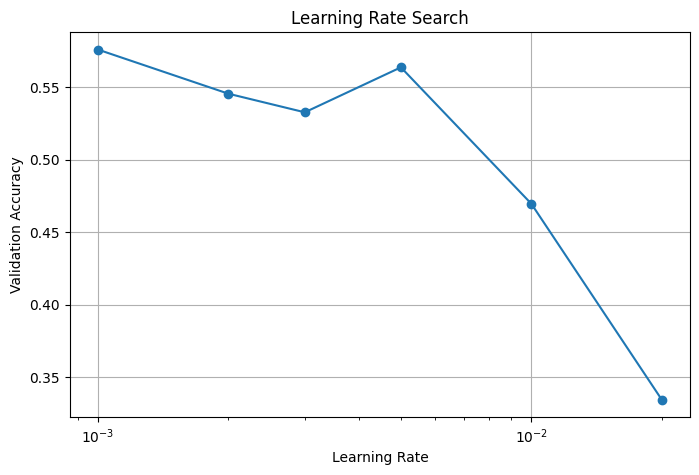

In [ ]:
import matplotlib.pyplot as plt

# Learning rates to test
learning_rates = [0.001,0.002,0.003,0.005,0.01,0.02]
epochs = 5

# Store validation accuracies
val_accuracies = []

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")

    config = {
        "image_size": 32,
        "hidden_size": 128,
        "num_classes": 10,
        "patch_size": 4,
        "num_channels": 3,
        "num_attention_heads": 4,
        "num_hidden_layers": 6,
        "intermediate_size": 512,
        "hidden_dropout_prob": 0.1,
        "attention_probs_dropout_prob": 0.1,
        "qkv_bias": True,
    }

    model = VisionTransformer(config)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    loss_fn = nn.CrossEntropyLoss()

    trainer = Trainer(model, optimizer, loss_fn, device)

    # Train the model and get the validation accuracy
    _, _, accuracies = trainer.train(train_loader, val_loader, epochs)
    val_accuracies.append(accuracies[-1])  # Save the final validation accuracy

# Plot the learning rates vs validation accuracies
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, val_accuracies, marker='o')
plt.xscale('log')  # Use a log scale for learning rates
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Learning Rate Search')
plt.grid()
plt.show()

## Experiment with Patch Size


Training with patch size: 2
Epoch 1/5


Validating: 100%|██████████| 79/79 [00:04<00:00, 16.42batch/s]


Train Loss: 1.8045, Validation Loss: 1.6379, Validation Accuracy: 0.3718
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:04<00:00, 16.48batch/s]


Train Loss: 1.4611, Validation Loss: 1.3464, Validation Accuracy: 0.5048
Epoch 3/5


...

Train Loss: 1.5531, Validation Loss: 1.4723, Validation Accuracy: 0.4738
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:01<00:00, 51.40batch/s]


Train Loss: 1.4622, Validation Loss: 1.3957, Validation Accuracy: 0.4904
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:01<00:00, 52.09batch/s]


Train Loss: 1.4046, Validation Loss: 1.3460, Validation Accuracy: 0.5122


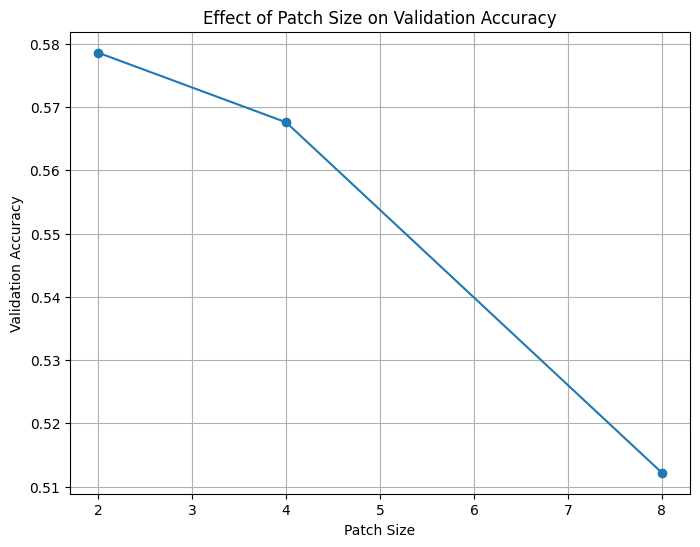

In [ ]:
# Patch sizes to experiment with
patch_sizes = [2, 4, 8]

# Dictionary to store validation accuracies for each patch size
validation_accuracies = {}

for patch_size in patch_sizes:
    print(f"\nTraining with patch size: {patch_size}")

    # Update the configuration with the current patch size.
    config["patch_size"] = patch_size
    config["hidden_size"] = 48  # Ensure hidden_size remains consistent
    config["intermediate_size"] = 4 * config["hidden_size"]  # Update intermediate size
    model = VisionTransformer(config)

    optimizer = torch.optim.AdamW(model.parameters(), lr= 0.001, weight_decay=0.01)  # Use best learning rate

    loss_fn = nn.CrossEntropyLoss()

    trainer = Trainer(model, optimizer, loss_fn, device)
    
    _, _, accuracies = trainer.train(train_loader, val_loader, 5)

    validation_accuracies[patch_size] = accuracies[-1]

# Plot the results
import matplotlib.pyplot as plt

# Plot the patch sizes (x-axis) vs. validation accuracies (y-axis).
plt.figure(figsize=(8, 6))
plt.plot(list(validation_accuracies.keys()), list(validation_accuracies.values()), marker='o')
plt.xlabel("Patch Size")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Patch Size on Validation Accuracy")
plt.grid()
plt.show()

## Experiment with Hidden Size

Training with hidden_size = 16
Epoch 1/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 32.19batch/s]


Train Loss: 1.9810, Validation Loss: 1.8172, Validation Accuracy: 0.2854
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:02<00:00, 31.93batch/s]


Train Loss: 1.7334, Validation Loss: 1.6510, Validation Accuracy: 0.3724
Epoch 3/5


...

Train Loss: 1.2078, Validation Loss: 1.1647, Validation Accuracy: 0.5706
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:06<00:00, 11.50batch/s]


Train Loss: 1.1155, Validation Loss: 1.1160, Validation Accuracy: 0.5980
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:07<00:00, 10.30batch/s]


Train Loss: 1.0499, Validation Loss: 1.0263, Validation Accuracy: 0.6348


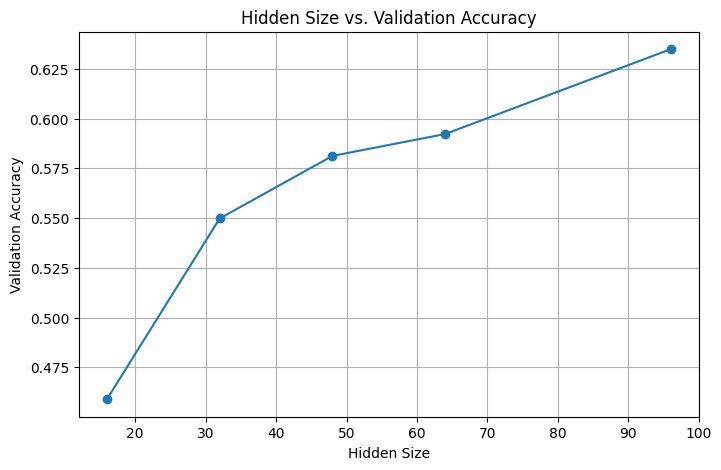

In [ ]:
# Different hidden sizes to experiment with
hidden_sizes = [16, 32, 48, 64, 96]

# Store validation accuracies for each hidden size
val_accuracies = []

for hidden_size in hidden_sizes:
    print(f"Training with hidden_size = {hidden_size}")
    config["hidden_size"] = hidden_size
    config["patch_size"] = 2
    config["intermediate_size"] = 4 * hidden_size  # Ensure intermediate size scales with hidden size
    config["num_attention_heads"] = max(1, hidden_size // 16)  # Adjust attention heads for valid division
    model = VisionTransformer(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()
    trainer = Trainer(model, optimizer, loss_fn, device)

    # Train the model and evaluate validation accuracy
    _, _, accuracies = trainer.train(train_loader, val_loader, epochs=5)
    val_accuracies.append(accuracies[-1])  # Record the last validation accuracy

# Plot validation accuracy vs. hidden size
plt.figure(figsize=(8, 5))
plt.plot(hidden_sizes, val_accuracies, marker='o')
plt.title("Hidden Size vs. Validation Accuracy")
plt.xlabel("Hidden Size")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

## Experiment with Number of Hidden Layers

Training with num_hidden_layers = 2
Epoch 1/5


Validating: 100%|██████████| 79/79 [00:03<00:00, 22.93batch/s]


Train Loss: 1.7651, Validation Loss: 1.5351, Validation Accuracy: 0.4256
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:03<00:00, 22.86batch/s]


Train Loss: 1.3977, Validation Loss: 1.3430, Validation Accuracy: 0.5080
Epoch 3/5


...

Train Loss: 1.2267, Validation Loss: 1.1860, Validation Accuracy: 0.5720
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:07<00:00, 10.28batch/s]


Train Loss: 1.1302, Validation Loss: 1.1596, Validation Accuracy: 0.5804
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:07<00:00, 10.30batch/s]

Train Loss: 1.0601, Validation Loss: 1.0744, Validation Accuracy: 0.6108


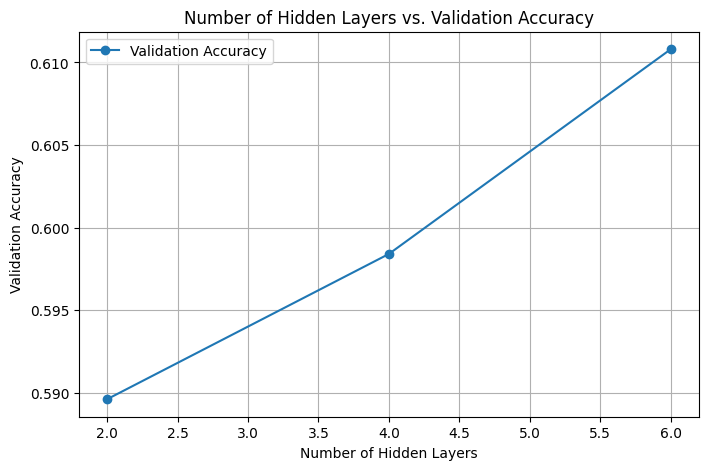

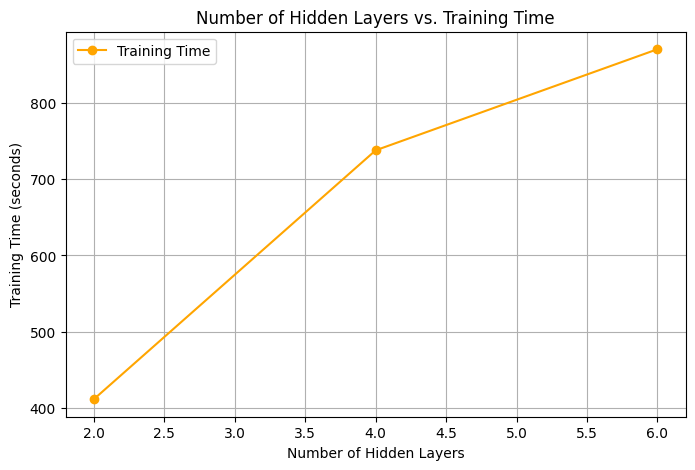

In [ ]:
import time

# Define the list of hidden layer configurations to experiment with
num_hidden_layers_list = [2, 4, 6]  # Different numbers of hidden layers to try
val_accuracies = []  # Store validation accuracies for each configuration
training_times = []  # Store training times for each configuration

# Iterate over each number of hidden layers
for num_hidden_layers in num_hidden_layers_list:
    print(f"Training with num_hidden_layers = {num_hidden_layers}")
    config["num_hidden_layers"] = num_hidden_layers
    config["hidden_size"] = 96
    config["patch_size"] = 2
    config["intermediate_size"] = 4 * config["hidden_size"]
    config["num_attention_heads"] = max(1, config["hidden_size"] // 16)
    model = VisionTransformer(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    # Instantiate the trainer
    trainer = Trainer(model, optimizer, loss_fn, device)
    start_time = time.time()
    _, _, accuracies = trainer.train(train_loader, val_loader, epochs=5)
    end_time = time.time()
    training_time = end_time - start_time
    val_accuracies.append(accuracies[-1])
    training_times.append(training_time)

# Plot validation accuracy vs. number of hidden layers
plt.figure(figsize=(8, 5))
plt.plot(num_hidden_layers_list, val_accuracies, marker='o', label="Validation Accuracy")
plt.title("Number of Hidden Layers vs. Validation Accuracy")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Plot training time vs. number of hidden layers
plt.figure(figsize=(8, 5))
plt.plot(num_hidden_layers_list, training_times, marker='o', color="orange", label="Training Time")
plt.title("Number of Hidden Layers vs. Training Time")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Training Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()

## Experiment with Number of Attention Heads

Training with num_attention_heads = 2
Epoch 1/5


Training:   0%|          | 0/704 [00:00<?, ?batch/s]

Validating: 100%|██████████| 79/79 [00:01<00:00, 40.88batch/s]


Train Loss: 1.8169, Validation Loss: 1.6283, Validation Accuracy: 0.3768
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:01<00:00, 39.95batch/s]


...

Train Loss: 1.2608, Validation Loss: 1.2970, Validation Accuracy: 0.5390
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:03<00:00, 23.34batch/s]


Train Loss: 1.1772, Validation Loss: 1.1255, Validation Accuracy: 0.5918
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:03<00:00, 23.36batch/s]


Train Loss: 1.1142, Validation Loss: 1.1453, Validation Accuracy: 0.5970


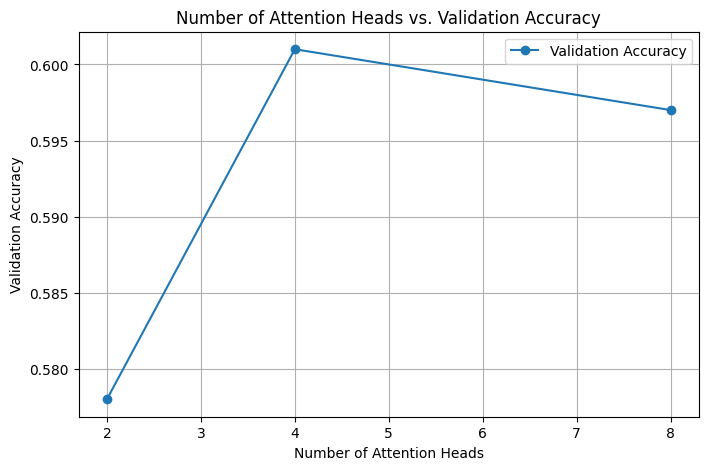

In [ ]:
# Define the list of attention head configurations to experiment with
num_attention_heads_list = [2, 4, 8]  # Different numbers of attention heads to try
val_accuracies = []  # Store validation accuracies for each configuration

# Iterate over each number of attention heads
for num_attention_heads in num_attention_heads_list:
    print(f"Training with num_attention_heads = {num_attention_heads}")
    config["num_hidden_layers"] = 2
    config["hidden_size"] = 96
    config["patch_size"] = 2
    config["num_attention_heads"] = num_attention_heads
    config["intermediate_size"] = 4 * config["hidden_size"]

    # Ensure that the hidden size is divisible by the number of attention heads
    assert config["hidden_size"] % config["num_attention_heads"] == 0, \
        "hidden_size must be divisible by num_attention_heads"

    model = VisionTransformer(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()
  
    # Instantiate the trainer
    trainer = Trainer(model, optimizer, loss_fn, device)

    # Train the model for 5 epochs and record the final validation accuracy
    _, _, accuracies = trainer.train(train_loader, val_loader, epochs=5)
    val_accuracies.append(accuracies[-1])

# Plot validation accuracy vs. number of attention heads
plt.figure(figsize=(8, 5))
plt.plot(num_attention_heads_list, val_accuracies, marker='o', label="Validation Accuracy")
plt.title("Number of Attention Heads vs. Validation Accuracy")
plt.xlabel("Number of Attention Heads")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

## Visualize Attention Maps

In [ ]:
def visualize_attention_maps(model, dataloader, num_per_class=2):
    """
    Visualize attention maps for `num_per_class` images per class.

    Parameters:
    - model: Trained Vision Transformer model.
    - dataloader: DataLoader for the dataset.
    - num_per_class: Number of images to visualize per class.
    """
    model.eval()  # Set the model to evaluation mode
    images_per_class = {i: 0 for i in range(10)}  # Track images per class
    images, attention_maps, classes = [], [], []

    with torch.no_grad():
        for images_batch, labels_batch in dataloader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
            outputs, attentions = model(images_batch, output_attentions=True)
            last_layer_attention = attentions[-1].mean(dim=1)

            for img, attn_map, label in zip(images_batch, last_layer_attention, labels_batch):
                if images_per_class[label.item()] < num_per_class:
                    images.append(img.cpu())
                    attention_maps.append(attn_map.cpu())
                    classes.append(label.item())
                    images_per_class[label.item()] += 1

                if all(count >= num_per_class for count in images_per_class.values()):
                    break

    # Normalize attention maps to [0, 1]
    attention_maps = [am / am.max() for am in attention_maps]

    # Define grid for visualization: 10 rows (classes) and 2 columns per image
    num_rows = 10
    num_cols = num_per_class * 2

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))

    for idx, (image, attn_map, cls) in enumerate(zip(images, attention_maps, classes)):
        row = cls
        col = (idx % num_per_class) * 2

        # Visualize the original image
        img = image.permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
        img = (img * 0.5 + 0.5).clamp(0, 1).numpy()  # De-normalize and clip to [0, 1]
        axs[row, col].imshow(img)
        axs[row, col].axis("off")
        axs[row, col].set_title(cifar10_classes[cls])  # Display class name

        # Visualize the attention map
        axs[row, col + 1].imshow(attn_map, cmap="cividis")  # Purple-yellow colormap
        axs[row, col + 1].axis("off")
        axs[row, col + 1].set_title("Attention Map")

    plt.tight_layout()
    plt.show()

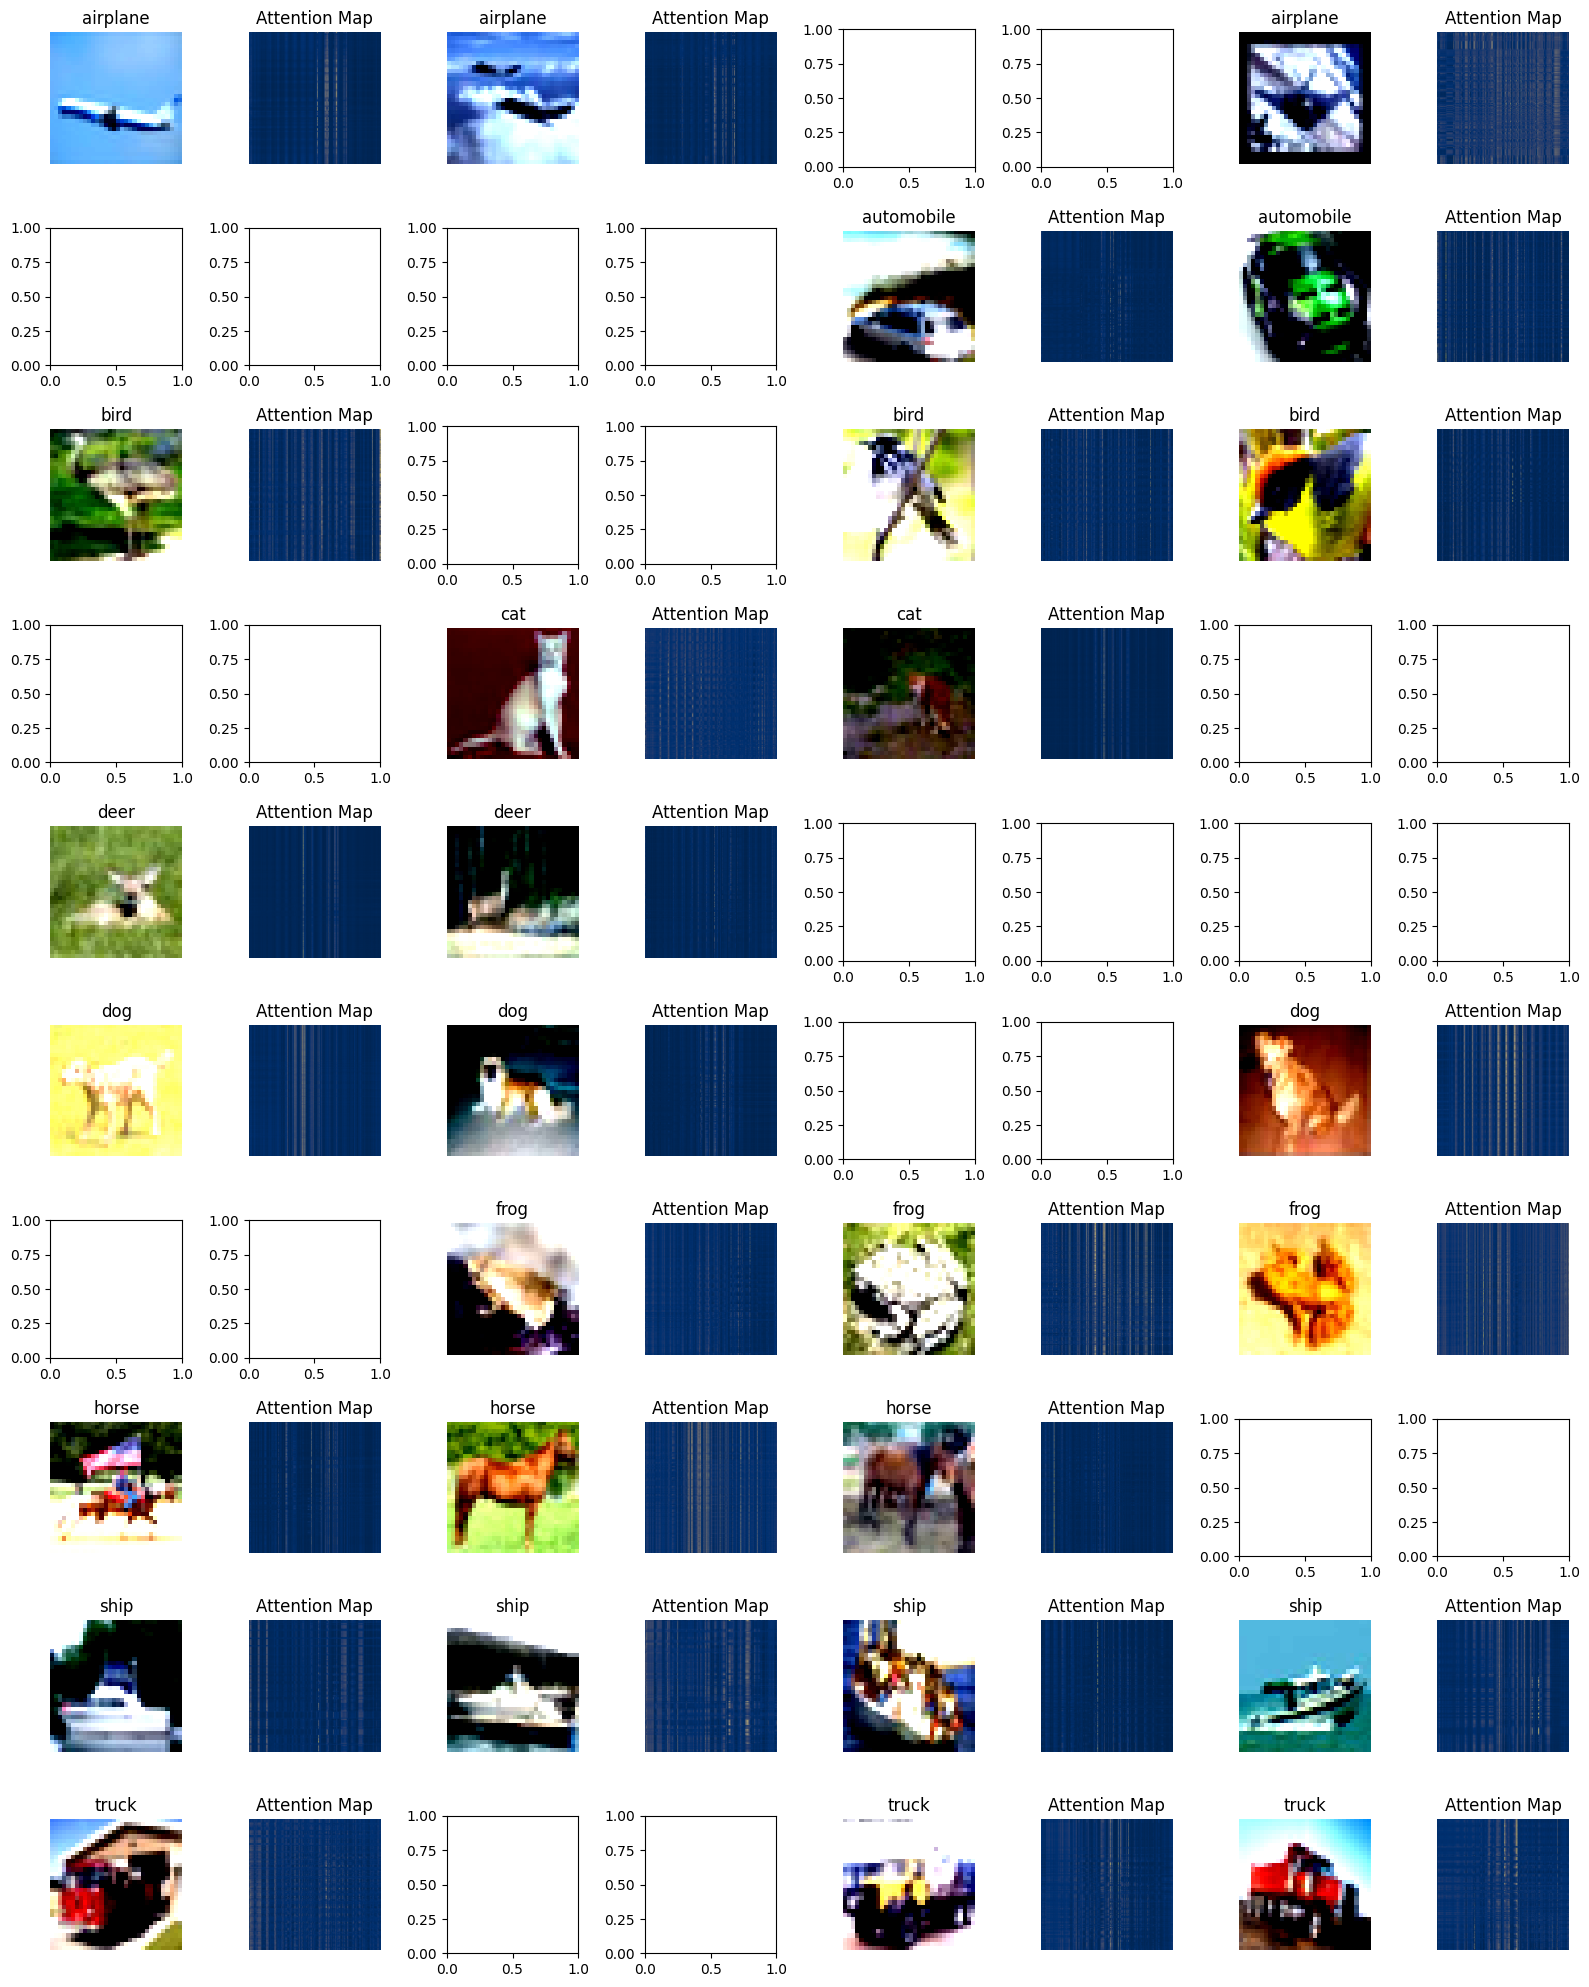

In [34]:
# Pass the validation DataLoader to visualize attention maps
visualize_attention_maps(model, val_loader, num_per_class=4)

# Fine-tune a pre-trained ViT-Tiny (ViT-T/16)

## Install `timm` library

In [35]:
!pip install timm


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\petro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Modify `Trainer`

In [36]:
class Trainer:
    def __init__(self, model, optimizer, loss_fn, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device

    def train_epoch(self, train_loader):
        """
        Train the model for one epoch with a progress bar.
        """
        self.model.train()
        total_loss = 0

        # Initialize tqdm progress bar
        with tqdm(train_loader, desc="Training", unit="batch") as t:
            for images, labels in t:
                images, labels = images.to(self.device), labels.to(self.device)

                # Zero gradients
                self.optimizer.zero_grad()

                # Forward pass
                logits = self.model(images)

                # Compute loss
                loss = self.loss_fn(logits, labels)

                # Backward pass
                loss.backward()

                # Update parameters
                self.optimizer.step()

                # Accumulate loss
                total_loss += loss.item() * len(images)

                # Update progress bar
                t.set_postfix(loss=loss.item())

        # Average loss
        return total_loss / len(train_loader.dataset)

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on the given dataloader with a progress bar.
        """
        self.model.eval()
        total_loss = 0
        correct = 0

        # Initialize tqdm progress bar
        with tqdm(dataloader, desc="Validating", unit="batch") as t:
            for images, labels in t:
                images, labels = images.to(self.device), labels.to(self.device)

                # Forward pass
                logits = self.model(images)

                # Compute loss
                loss = self.loss_fn(logits, labels)
                total_loss += loss.item() * len(images)

                # Compute accuracy
                predictions = torch.argmax(logits, dim=1)
                correct += (predictions == labels).sum().item()

        accuracy = correct / len(dataloader.dataset)
        avg_loss = total_loss / len(dataloader.dataset)

        return accuracy, avg_loss

    def train(self, train_loader, val_loader, epochs):
        """
        Train the model for the specified number of epochs.
        """
        train_losses, val_losses, accuracies = [], [], []

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs}")

            # Train for one epoch
            train_loss = self.train_epoch(train_loader)

            # Evaluate on the val set
            accuracy, val_loss = self.evaluate(val_loader)

            # Record metrics
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            accuracies.append(accuracy)

            # Print epoch metrics
            print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {accuracy:.4f}")

        # Return the training history
        return train_losses, val_losses, accuracies

C:\Users\petro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files already downloaded and verified
Files already downloaded and verified
Loading pre-trained ViT-Tiny model...
Starting fine-tuning...
Epoch 1/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.50batch/s]


Train Loss: 1.7015, Validation Loss: 1.3736, Validation Accuracy: 0.5058
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.50batch/s]


...

Train Loss: 1.0276, Validation Loss: 0.9923, Validation Accuracy: 0.6504
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.50batch/s]


Train Loss: 0.8879, Validation Loss: 1.0043, Validation Accuracy: 0.6488
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.36batch/s]

Train Loss: 0.7932, Validation Loss: 0.8754, Validation Accuracy: 0.6948


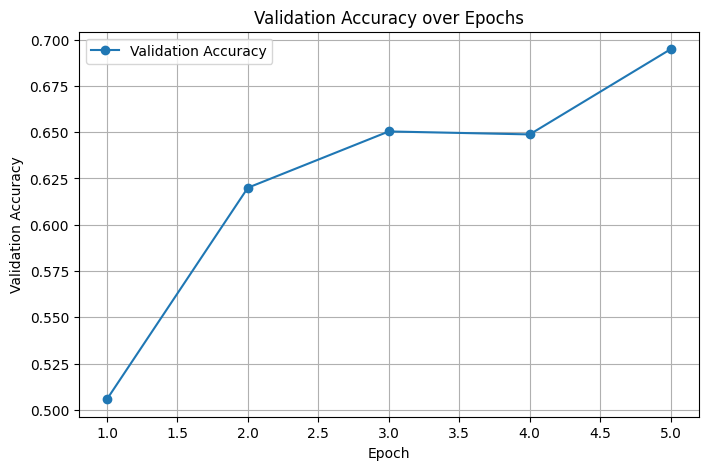

In [ ]:
# Import necessary libraries
from timm import create_model
from torch.utils.data import DataLoader, random_split

# Define the mean and standard deviation for CIFAR-10
mean = (0.4914, 0.4822, 0.4465)  # Precomputed mean for CIFAR-10
std = (0.2023, 0.1994, 0.2010)   # Precomputed std for CIFAR-10

# Define dataset path
dataset_path = '/content/drive/MyDrive/labs/'

transform_resized = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Use the same number of images for train, val, and test splits
num_train = 45000  # Number of training examples
num_val = 5000    # Number of validation examples
num_test = 10000   # Number of test examples (CIFAR-10 test set size)

dataset = datasets.CIFAR10(root=dataset_path, train=True, download=True, transform=transform_resized)
test_dataset = datasets.CIFAR10(root=dataset_path, train=False, download=True, transform=transform_resized)

train_dataset, val_dataset = random_split(dataset, [num_train, num_val])

# Use the same batch size as before
batch_size = 64

train_loader_resized = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_resized = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader_resized = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load the pre-trained ViT-Tiny model from timm
print("Loading pre-trained ViT-Tiny model...")
model = create_model(
    "vit_tiny_patch16_224",  # Pre-trained ViT-Tiny on ImageNet-1k
    pretrained=True,        # Load pre-trained weights
    num_classes=10          # Adapt classifier head to CIFAR-10 (10 classes)
)

# Define optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()

# Instantiate the trainer
trainer = Trainer(model, optimizer, loss_fn, device)

# Train the model for 5 epochs
print("Starting fine-tuning...")
train_losses, val_losses, accuracies = trainer.train(train_loader_resized, val_loader_resized, epochs=5)

# Plot validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', label="Validation Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Fine-tune only the classifier of a ViT-Tiny (ViT-T/16)

Epoch 1/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.50batch/s]


Train Loss: 0.8314, Validation Loss: 0.7289, Validation Accuracy: 0.7474
Epoch 2/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.52batch/s]


Train Loss: 0.6968, Validation Loss: 0.7025, Validation Accuracy: 0.7552
Epoch 3/5


...

Train Loss: 0.6795, Validation Loss: 0.7156, Validation Accuracy: 0.7490
Epoch 4/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.48batch/s]


Train Loss: 0.6724, Validation Loss: 0.7058, Validation Accuracy: 0.7576
Epoch 5/5


Validating: 100%|██████████| 79/79 [00:14<00:00,  5.48batch/s]

Train Loss: 0.6690, Validation Loss: 0.7113, Validation Accuracy: 0.7488


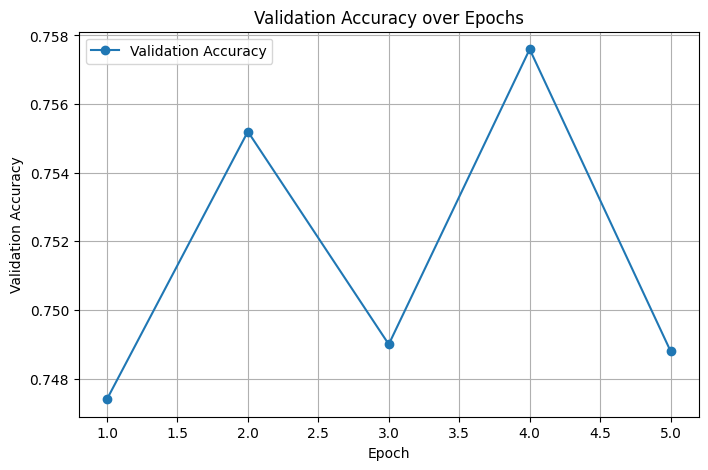

In [ ]:
import torch.optim as optim

model = create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=10
)

# Freeze all layers except the classifier
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier layer
for param in model.head.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.head.parameters(), lr=0.001, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()

# Instantiate the trainer
trainer = Trainer(model, optimizer, loss_fn, device)

# Train the model for 5 epochs
train_losses, val_losses, accuracies = trainer.train(train_loader_resized, val_loader_resized, epochs=5)

# Plot validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', label="Validation Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Fine-tune only the classifier of a ViT-Base (ViT-B/16)

C:\Users\petro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\petro\.cache\huggingface\hub\models--timm--vit_base_patch16_224.augreg2_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Epoch 1/5


Validating: 100%|██████████| 79/79 [01:05<00:00,  1.21batch/s]


Train Loss: 0.2473, Validation Loss: 0.1950, Validation Accuracy: 0.9352
Epoch 2/5


Validating: 100%|██████████| 79/79 [01:05<00:00,  1.21batch/s]


...

Train Loss: 0.1494, Validation Loss: 0.1867, Validation Accuracy: 0.9366
Epoch 4/5


Validating: 100%|██████████| 79/79 [01:06<00:00,  1.20batch/s]


Train Loss: 0.1402, Validation Loss: 0.1804, Validation Accuracy: 0.9412
Epoch 5/5


Validating: 100%|██████████| 79/79 [01:06<00:00,  1.18batch/s]

Train Loss: 0.1349, Validation Loss: 0.1946, Validation Accuracy: 0.9392


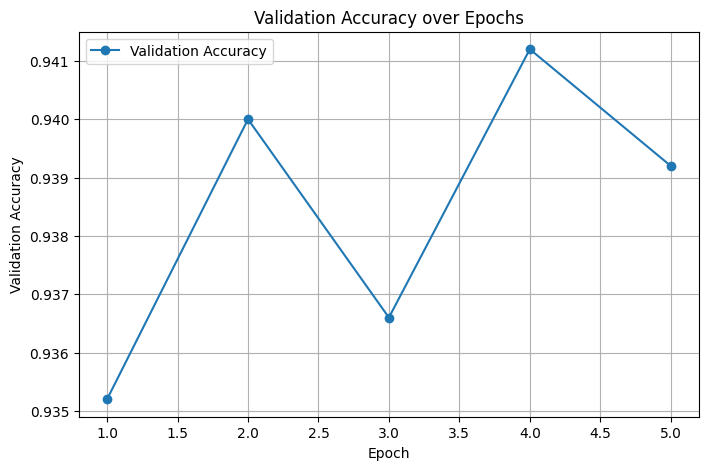

In [ ]:
model = create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=10
)

# Freeze all layers except the classifier
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier layer
for param in model.head.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.head.parameters(), lr=0.001, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()

# Instantiate the trainer
trainer = Trainer(model, optimizer, loss_fn, device)

# Train the model for 5 epochs
train_losses, val_losses, accuracies = trainer.train(train_loader_resized, val_loader_resized, epochs=5)

# Plot validation accuracy over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', label="Validation Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Evaluate the best model on the test set of CIFAR-10

In [40]:
test_acc, test_loss = trainer.evaluate(test_loader_resized)

Validating: 100%|██████████| 157/157 [02:04<00:00,  1.26batch/s]


In [41]:
print(f'Accuracy on CIFAR-10 test set: {test_acc*100}%')

Accuracy on CIFAR-10 test set: 93.86%


# Technical Report

Custom Vision Transformer:

1. Observations from Hyperparameter Tuning

1.1 Learning Rate

Observations:

Learning rates of 0.001 and 0.002 consistently yielded better validation accuracy compared to higher learning rates like 0.01 and 0.02.

Extremely high learning rates (≥ 0.01) led to instability in training, evidenced by erratic training loss and poor validation accuracy.

Moderate learning rates (0.001 and 0.002) allowed for steady improvement in validation accuracy, achieving a maximum of ~0.58 accuracy.

Conclusion:

Smaller learning rates are more stable for training Vision Transformers, enabling convergence to better optima.

1.2 Patch Size

Observations:

Smaller patch sizes (e.g., 2) resulted in higher validation accuracy (~0.5786) but increased training time due to the larger input sequence.

Larger patch sizes (e.g., 8) reduced computational cost but led to a drop in accuracy, achieving a maximum of ~0.5122 accuracy.

Conclusion:

Smaller patches capture more fine-grained spatial information but increase computational overhead.

A trade-off exists between computational efficiency and accuracy, depending on the patch size.

1.3 Hidden Size

Observations:

Increasing the hidden size from 16 to 96 led to progressive improvements in validation accuracy, with the highest being ~0.6348 accuracy at hidden size 96.

Larger hidden sizes significantly increased training time, with hidden size 96 requiring over 3 minutes per epoch.

Conclusion:

Higher hidden sizes enhance the model's capacity to learn complex representations but at the cost of increased training time and computational resources.

1.4 Number of Layers

Observations:

Models with 2 hidden layers achieved validation accuracy of ~0.5896, while models with 6 hidden layers improved accuracy to ~0.6108.

Training time increased drastically with more layers, with 6-layer models taking over 3 minutes per epoch compared to 1.3 minutes for 2-layer models.

Conclusion:

Deeper models tend to perform better but require significantly more time and computational resources, reflecting the classic depth-performance trade-off.

1.5 Number of Attention Heads

Observations:

Increasing attention heads from 2 to 8 improved validation accuracy from ~0.5780 to ~0.5970.

The computational cost grew noticeably with more attention heads, impacting training time.

Conclusion:

Higher attention heads improve performance by enabling more diverse feature extraction, but this benefit diminishes with excessive heads due to increased computational requirements.

2. Trade-offs Between Model Complexity and Performance

2.1 Computational Efficiency vs. Accuracy

Impact of Complexity:

Smaller patch sizes, larger hidden sizes, deeper networks, and higher attention heads contribute to better performance but increase computational demands.

Simpler configurations (e.g., larger patch sizes, fewer layers) reduce training time but compromise accuracy.

2.2 Stability vs. Performance

Learning Rate Trade-offs:

Lower learning rates provide stable convergence but require more epochs to achieve optimal accuracy.

Higher learning rates accelerate training but risk instability and poor generalization.

2.3 Model Depth vs. Generalization

Deeper models generally perform better on validation accuracy, but beyond a certain point, gains become marginal compared to the additional training cost.


Visualization of Attention Maps:


1. Insights from Visualizing Attention Maps

1.1 Focus on Relevant Features:

The attention maps indicate that the model is focusing on specific regions of the input images that are most relevant to the classification task.

For example:

In images of airplanes, attention is directed to the wings and fuselage.

In animals like cats or dogs, attention is centered on the body, head, or distinctive features like eyes.

1.2 Class-Specific Attention Patterns:

Different classes exhibit distinct attention patterns.

For vehicles (e.g. trucks), the model often focuses on the chassis and wheels.

For animals (e.g. birds, horses), the attention appears to emphasize body contours or unique color patterns.

1.3 Areas of Weak or Uniform Attention:

In some cases, attention maps appear more uniform, which might indicate uncertainty in the model or a lack of distinctive features in the image.

Such uniformity could be an indicator of misclassification potential or room for improvement in feature extraction.

2. Understanding the Model’s Focus Using Visualizations:

2.1 Model Interpretability:

The visualizations provide a window into how the model processes input images, making the decision-making process less opaque.

This interpretability is crucial for building trust in Vision Transformer models, especially in critical applications

2.2 Error Analysis:

By comparing attention maps for correctly and incorrectly classified images, insights can be drawn about potential shortcomings in the model's focus.

For example, if the model attends to background noise instead of the object of interest, it highlights areas for model improvement.

2.3 Feature Importance:

Attention maps emphasize which parts of the image contribute most to the final decision. This helps validate whether the model's focus aligns with human intuition.

2.4 Model Debugging and Optimization:

If attention maps show consistent misfocus across certain classes, it may point to issues in the dataset (e.g., noisy labels or insufficient diversity) or in the model architecture.

3. Fine-tuning Pre-trained Vision Transformers: Analysis

3.1 Fine-tuning the Entire ViT-Tiny Model vs. Custom Vision Transformer
Validation Accuracy:

Fine-tuning the entire ViT-Tiny model achieved a validation accuracy of 69.48% after 5 epochs.

A custom Vision Transformer trained from scratch is likely to achieve lower accuracy within the same timeframe due to the absence of pre-trained weights and reliance on learning features entirely from the CIFAR-10 dataset.

Performance Differences:

ViT-Tiny Model: Benefits from transfer learning; the pre-trained backbone already possesses robust feature representations that adapt effectively to CIFAR-10 with fine-tuning.

Custom Vision Transformer: Requires significantly more training data and epochs to reach similar levels of accuracy, making it computationally expensive and slower to converge.

3.2 Fine-tuning the Entire ViT-Tiny Model vs. Fine-tuning Only the Classifier

Validation Accuracy:

Fine-tuning the entire ViT-Tiny model: 69.48% validation accuracy.

Fine-tuning only the classifier of ViT-Tiny: 75.76% validation accuracy.

Performance Differences:

Entire Model Fine-tuning: Allows all layers, including the pre-trained backbone, to adapt to the target dataset. This is useful if the dataset has features significantly different from those learned during pre-training.

Classifier Fine-tuning: Freezes the backbone, leveraging pre-trained features directly while adapting only the classifier. For datasets like CIFAR-10, where pre-trained features are highly relevant, this approach is computationally efficient and achieves better performance.

3.3 Training Only the Classifier of ViT-Base vs. Fine-tuning the Entire ViT-Tiny

Validation Accuracy:

Fine-tuning only the classifier of ViT-Base: 94.12% validation accuracy.

Fine-tuning the entire ViT-Tiny model: 69.48% validation accuracy.

Fine-tuning only the classifier of ViT-Tiny: 0.7488 validation accuracy.

Performance Differences:

ViT-Base Classifier Fine-tuning: Achieves higher accuracy because of the larger model capacity and more expressive pre-trained features. Even with the backbone frozen, the classifier adapts effectively to CIFAR-10.

ViT-Tiny Entire Model Fine-tuning: Has limited capacity compared to ViT-Base and requires all layers to adapt to CIFAR-10, which is less efficient for small datasets.

4. General Observations

Effectiveness of Custom ViT vs. Pre-trained Models for CIFAR-10

4.1 Performance of the Custom ViT:

Custom Vision Transformers (ViTs) trained from scratch on CIFAR-10 require significantly more epochs and computational resources to achieve competitive accuracy.

They start learning from random initialization, which limits their ability to capture complex features in small datasets like CIFAR-10.

4.2 Performance of Pre-trained Models:

Pre-trained models (ViT-Tiny and ViT-Base) significantly outperformed the custom Vision Transformer.

Fine-tuning the Pre-trained ViT-B/16 Classifier:

Achieved 93.86% test accuracy, which is state-of-the-art for CIFAR-10 within this experimental setup.
Demonstrates the power of transfer learning and the robustness of pre-trained features.

Fine-tuning the Pre-trained ViT-Tiny:
Achieved 69.48% validation accuracy when the entire model was fine-tuned.
Showed competitive performance relative to its smaller size and computational efficiency.

5. Discussion: Computational Efficiency and Validation Accuracy Trade-offs

1.Custom Vision Transformer vs. Pre-trained Models

Computational Efficiency:

Training a custom Vision Transformer (ViT) from scratch requires significantly more computational resources due to:
Random initialization of weights.

A larger number of epochs needed to converge.

Pre-trained models, such as ViT-Tiny and ViT-Base, benefit from pre-trained weights on ImageNet, drastically reducing training time.

Validation Accuracy:

Custom ViT: Likely achieves lower accuracy compared to pre-trained models within the same number of epochs due to limited feature learning from scratch.

Pre-trained Models: Fine-tuning pre-trained models yields superior accuracy as they leverage robust feature representations.

Trade-off:
Pre-trained models are far more computationally efficient and achieve better validation accuracy than custom ViTs.

2.Fine-tuning the Entire Model vs. Fine-tuning Only the Classifier

Computational Efficiency:

Fine-tuning the entire model requires updating all parameters, leading to higher computational costs.

Fine-tuning only the classifier freezes the backbone, reducing training time and GPU memory usage.

Validation Accuracy:

Fine-tuning only the classifier achieved better validation accuracy for ViT-Tiny (75.76%) compared to fine-tuning the entire model (69.48%).

This suggests that the pre-trained backbone was already well-suited for CIFAR-10, and adapting only the classifier was sufficient.

Trade-off:
Fine-tuning the entire model is computationally expensive but allows for greater flexibility when the pre-trained features are not perfectly aligned with the target dataset.
Fine-tuning only the classifier is efficient and performs well when pre-trained features are highly relevant.

3.ViT-Tiny vs. ViT-Base (Pre-trained Models)

Computational Efficiency:

ViT-Tiny, being a smaller model, trains significantly faster and requires less memory.

ViT-Base, with its larger size and higher parameter count, is computationally intensive, especially when training even just the classifier.

Validation Accuracy:

Fine-tuning only the classifier of ViT-Base achieved a remarkable 94.12% validation accuracy and 93.86% test accuracy.

Fine-tuning ViT-Tiny, even the entire model, achieved a much lower accuracy of 69.48%, indicating its limited capacity for complex feature extraction.

Trade-off:
ViT-Tiny is computationally efficient but sacrifices accuracy.
ViT-Base delivers superior accuracy but at a higher computational cost.

4.Specific Observations from Results

Epoch-wise Trends:

Larger models like ViT-Base show smaller improvements per epoch but achieve higher overall accuracy due to their capacity.

Smaller models like ViT-Tiny converge faster but plateau at lower accuracy.

Data Suitability:
Pre-trained models perform exceptionally well when the target dataset (CIFAR-10) shares features with the pre-training dataset (ImageNet).

Conclusion :

Efficiency vs. Accuracy: There is a clear trade-off between computational efficiency and validation accuracy. Smaller models (e.g., ViT-Tiny) are efficient and suitable for applications with resource constraints, while larger models (e.g., ViT-Base) are preferred for applications demanding high accuracy.

Best Practice: Fine-tuning only the classifier of ViT-Base is the best approach for CIFAR-10, achieving state-of-the-art accuracy with moderate computational efficiency.

